/home/cihat/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


EDMD Lifted State Shape: (2048, 64) (Eksiksiz!)


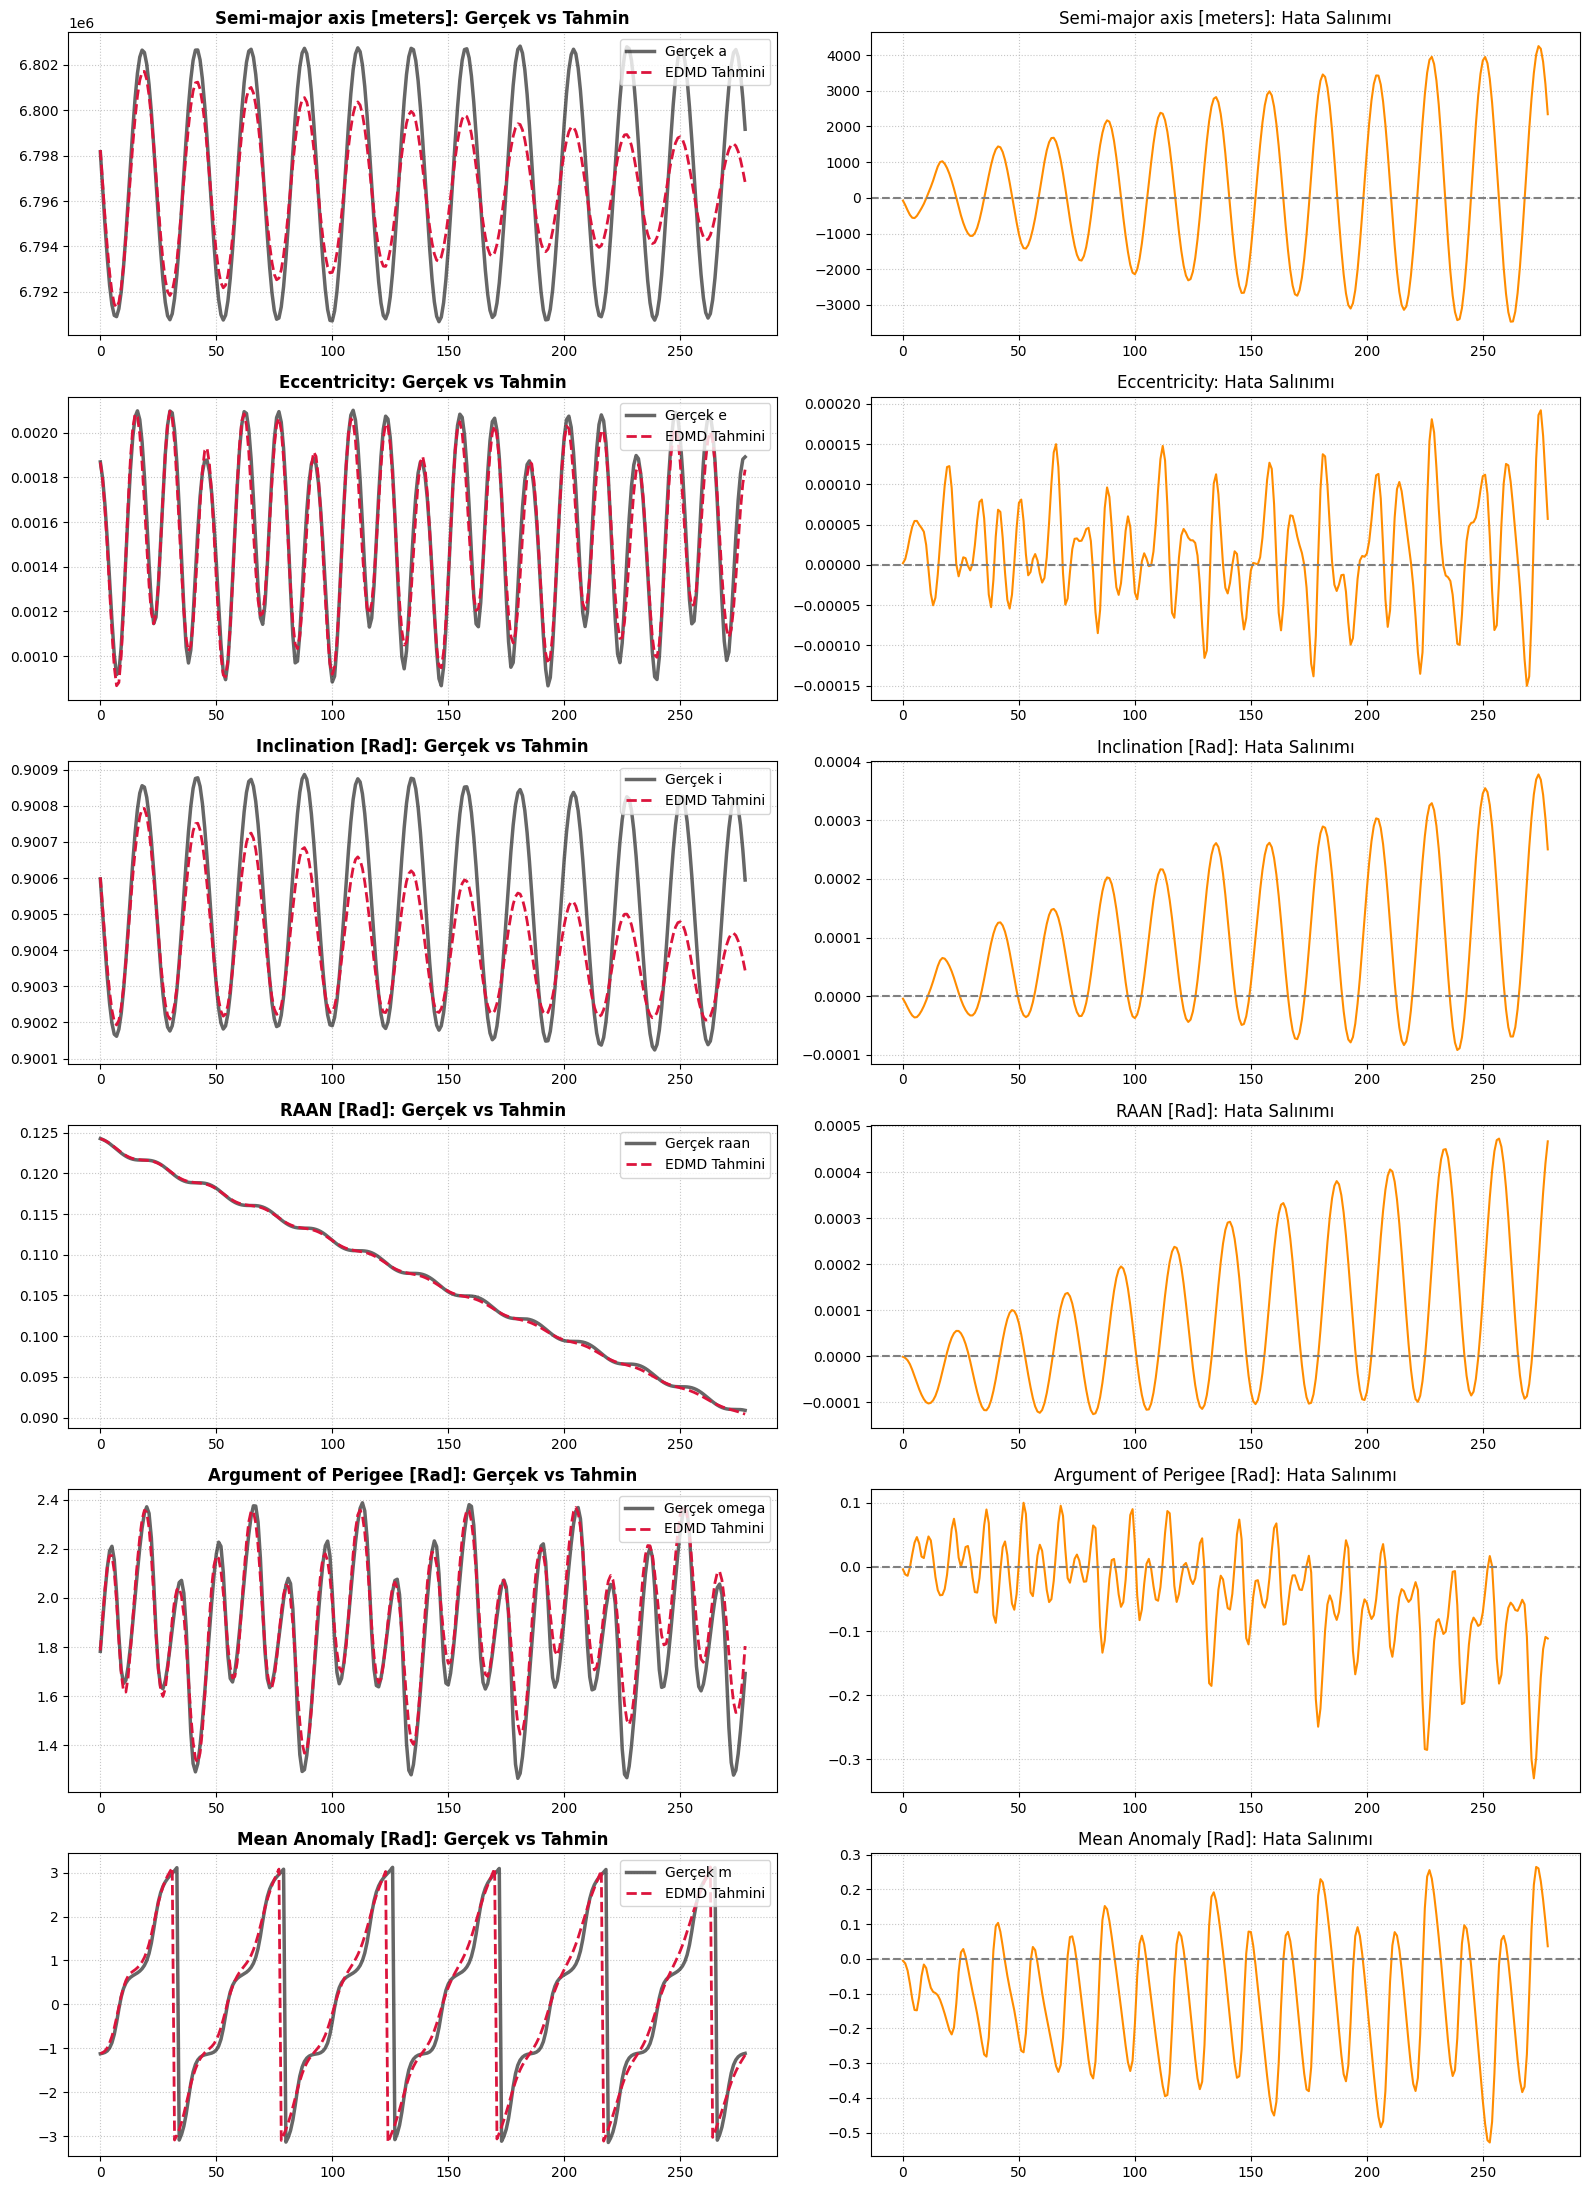

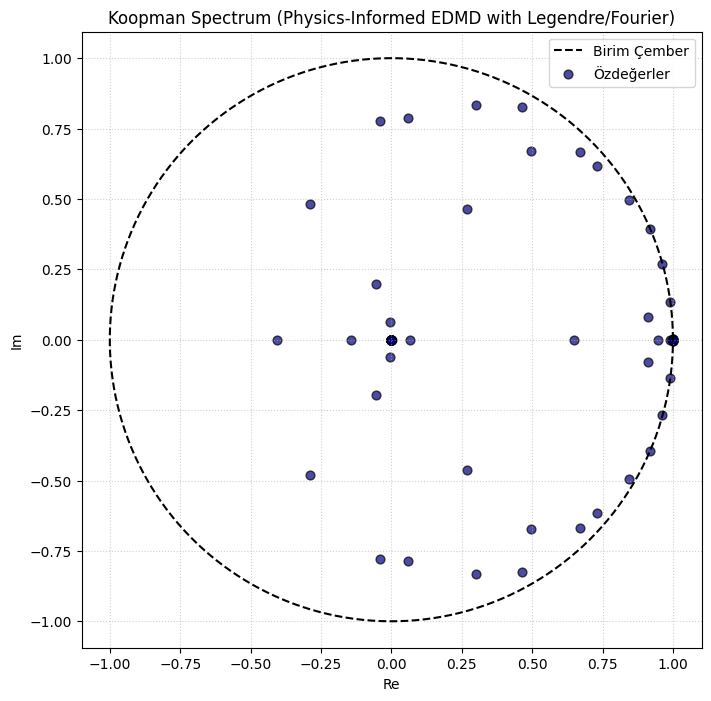

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import eval_legendre
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import Ridge
import warnings

warnings.filterwarnings("ignore")

DEGREE = 6
TARGET_ORBITS = 6

# ==============================================================================
# 1. VERİ OKUMA VE HAZIRLIK
# ==============================================================================
df_raw = pd.read_csv("raw_orbit_data.csv")

mu = 3.986004418e14   
R_e = 6378137.0       
J2_const = 1.0826e-3  

mean_a = df_raw['a'].mean()
T_seconds = 2 * np.pi * np.sqrt((mean_a**3) / mu)
T_hours = T_seconds / 3600.0

delta_t_hours = df_raw['t_hours'].iloc[1] - df_raw['t_hours'].iloc[0]
steps_per_orbit = T_hours / delta_t_hours
TEST_SIZE = int(np.ceil(TARGET_ORBITS * steps_per_orbit))

N_forecast = TEST_SIZE
N_train = len(df_raw) - N_forecast

train_df = df_raw.iloc[:N_train].copy().reset_index(drop=True)
test_df = df_raw.iloc[N_train:N_train + N_forecast].copy().reset_index(drop=True)

# Sadece a ve e'yi ezeceğiz, çünkü Legendre polinomları (-1, 1) dışında patlar!
scaler_ae = MinMaxScaler(feature_range=(-1, 1))
scaler_ae.fit(train_df[['a', 'e']])

# ==============================================================================
# 2. LIFTING (EDMD + FİZİK + BİAS KOMBİNASYONU)
# ==============================================================================
def create_lifted_state(df_input):
    df_proc = df_input.copy()
    math_features = {}
    
    # 1. BİAS (Sönümlenmeyi kesinlikle engeller)
    math_features['bias'] = np.ones(len(df_proc))
    
    # 2. TEMEL DEĞERLER (a ve e scale ediliyor)
    scaled_ae = scaler_ae.transform(df_proc[['a', 'e']])
    math_features['a'] = scaled_ae[:, 0]
    math_features['e'] = scaled_ae[:, 1]
    
    # 3. TEMEL AÇILAR (1. Derece Fourier - Geri dönüşüm için şart)
    for angle in ['i', 'raan', 'omega', 'm']:
        math_features[f'sin_1{angle}'] = np.sin(df_proc[angle].values)
        math_features[f'cos_1{angle}'] = np.cos(df_proc[angle].values)
        
    # 4. FİZİKSEL TERİMLER (Bunları ASLA ölçeklendirmiyoruz, fiziksel doğası kalıyor)
    n_raw = np.sqrt(mu / (df_proc['a'].values**3))
    p_term = df_proc['a'].values * (1 - df_proc['e'].values**2)
    J2_factor = 1.5 * J2_const * (R_e / p_term)**2 * n_raw
    
    math_features['mean_motion_n'] = n_raw
    math_features['J2_raan_term'] = J2_factor * np.cos(df_proc['i'].values)
    math_features['J2_omega_term'] = J2_factor * (4 - 5 * (np.sin(df_proc['i'].values)**2))

    # 5. GERÇEK EDMD: LEGENDRE POLİNOMLARI (2'den 6'ya kadar)
    for col in ['a', 'e']:
        x = math_features[col]
        for d in range(2, DEGREE + 1):
            math_features[f"{col}_P{d}"] = eval_legendre(d, x)
            
    # 6. GERÇEK EDMD: YÜKSEK DERECELİ FOURIER (2'den 6'ya kadar)
    for angle in ['i', 'raan', 'omega', 'm']:
        val = df_proc[angle].values
        for d in range(2, DEGREE + 1):
            math_features[f"sin_{d}{angle}"] = np.sin(d * val)
            math_features[f"cos_{d}{angle}"] = np.cos(d * val)
            
    df_lifted = pd.DataFrame(math_features)
    
    # İNDEKSLERİ SABİTLİYORUZ (Geri dönüşümde hata çıkmaması için KESİN SIRA)
    base_cols = [
        'bias', 
        'a', 'e', 
        'sin_1i', 'cos_1i', 
        'sin_1raan', 'cos_1raan', 
        'sin_1omega', 'cos_1omega', 
        'sin_1m', 'cos_1m'
    ]
    other_cols = [c for c in df_lifted.columns if c not in base_cols]
    final_cols = base_cols + other_cols
    
    return df_lifted[final_cols].values

Z_train = create_lifted_state(train_df)
Z1_train = Z_train[:-1]
Z2_train = Z_train[1:]

print(f"EDMD Lifted State Shape: {Z_train.shape} (Eksiksiz!)")

# ==============================================================================
# 3. K MATRİSİ EĞİTİMİ (RIDGE)
# ==============================================================================
# Fiziksel J2 terimleri çok küçük olduğu için alpha'yı aşırı düşük tutuyoruz (1e-12)
model = Ridge(alpha=1e-12, fit_intercept=False)
model.fit(Z1_train, Z2_train)
K = model.coef_

# ==============================================================================
# 4. TAHMİN (FORECAST) DÖNGÜSÜ
# ==============================================================================
z_current = Z_train[-1].copy()
Z_forecast = []

for step in range(N_forecast):
    z_next = z_current @ K.T
    
    # Koopman matrisi çarpa çarpa Bias'ı (1.0) bozabilir. Zorla 1.0 yapıyoruz.
    z_next[0] = 1.0 
    
    Z_forecast.append(z_next)
    z_current = z_next.copy()

Z_forecast = np.array(Z_forecast)

# ==============================================================================
# 5. GERİ DÖNÜŞÜM (UNLIFTING)
# ==============================================================================
pred_raw_future = pd.DataFrame(index=range(N_forecast))

# a ve e (İndeks 1 ve 2)
pred_raw_future[['a', 'e']] = scaler_ae.inverse_transform(Z_forecast[:, 1:3])

# Temel Açılar (İndeks 3'ten 10'a kadar)
pred_raw_future['i']     = np.arctan2(Z_forecast[:, 3], Z_forecast[:, 4])
pred_raw_future['raan']  = np.arctan2(Z_forecast[:, 5], Z_forecast[:, 6])
pred_raw_future['omega'] = np.arctan2(Z_forecast[:, 7], Z_forecast[:, 8])
pred_raw_future['m']     = np.arctan2(Z_forecast[:, 9], Z_forecast[:, 10])

# ==============================================================================
# 6. HATALARIN HESAPLANMASI
# ==============================================================================
errors = pd.DataFrame()
angles = ['i', 'omega', 'raan', 'm']
true_raw_future = test_df.copy()

for col in ['a', 'e', 'i', 'raan', 'omega', 'm']:
    true_vals = true_raw_future[col].values
    pred_vals = pred_raw_future[col].values

    if col in angles:
        errors[col] = np.arctan2(np.sin(true_vals - pred_vals), np.cos(true_vals - pred_vals))
    else:
        errors[col] = true_vals - pred_vals

# ==============================================================================
# 7. GRAFİKLERİN ÇİZDİRİLMESİ
# ==============================================================================
feature_names = {
    'a': 'Semi-major axis [meters]', 'e': 'Eccentricity',
    'i': 'Inclination [Rad]', 'raan': 'RAAN [Rad]',
    'omega': 'Argument of Perigee [Rad]', 'm': 'Mean Anomaly [Rad]'
}

fig, axes = plt.subplots(6, 2, figsize=(16, 22))

for idx, col in enumerate(['a', 'e', 'i', 'raan', 'omega', 'm']):
    name = feature_names[col]
    true_vals = true_raw_future[col].values
    pred_vals = pred_raw_future[col].values
    error_vals = errors[col].values

    ax_comp = axes[idx, 0]
    ax_comp.plot(true_vals, label=f"Gerçek {col}", color="black", linewidth=2.5, alpha=0.6)
    ax_comp.plot(pred_vals, "--", label="EDMD Tahmini", color="crimson", linewidth=2.0)
    ax_comp.set_title(f"{name}: Gerçek vs Tahmin", fontweight="bold")
    ax_comp.grid(True, linestyle=":", alpha=0.7)
    ax_comp.legend(loc="upper right")

    ax_err = axes[idx, 1]
    ax_err.plot(error_vals, color="darkorange", linewidth=1.5)
    ax_err.axhline(0, color="gray", linestyle="--", linewidth=1.5)
    ax_err.set_title(f"{name}: Hata Salınımı")
    ax_err.grid(True, linestyle=":", alpha=0.7)

plt.tight_layout()
plt.show()

# ==============================================================================
# 8. KOOPMAN SPEKTRUMU
# ==============================================================================
eigvals = np.linalg.eigvals(K)
plt.figure(figsize=(8, 8))
theta = np.linspace(0, 2 * np.pi, 200)
plt.plot(np.cos(theta), np.sin(theta), 'k--', linewidth=1.5, label='Birim Çember')
plt.scatter(eigvals.real, eigvals.imag, color='navy', alpha=0.7, edgecolors='k', s=40, label='Özdeğerler')
plt.title("Koopman Spectrum (Physics-Informed EDMD with Legendre/Fourier)")
plt.xlabel("Re")
plt.ylabel("Im")
plt.axis("equal")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.show()